In [25]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Downloading NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

# Loading the dataset
df = pd.read_csv('OCCU_Loan_Data.csv')

# Viewing first few rows
df.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dhyey\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dhyey\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\dhyey\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,ID,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,activity,sector,country,region
0,0,67.0,male,2.0,own,NaN,little,1.169230e+40,6.0,"To buy seasonal, fresh fruits to sell.",good,Fruits & Vegetables,Food,Pakistan,Lahore
1,1,22.0,female,2.0,own,little,moderate,5.951000e+03,48.0,to repair and maintain the auto rickshaw used ...,bad,Rickshaw,Transportation,Pakistan,Lahore
2,2,49.0,male,1.0,own,little,NaN,2.096000e+03,12.0,To repair their old cycle-van and buy another ...,good,Transportation,Transportation,India,Maynaguri
3,3,45.0,male,2.0,free,little,little,7.882000e+03,42.0,to purchase an embroidery machine and a variet...,good,Embroidery,Arts,Pakistan,Lahore
4,4,53.0,male,2.0,free,little,little,4.870000e+03,24.0,to purchase one buffalo.,bad,Milk Sales,Food,Pakistan,Abdul Hakeem


### Data Wrangling & Categorical Encoding

In [26]:
# Checking for missing values and fill/drop them
print(df.isnull().sum())
df = df.dropna()

# Categorical Encoding for Demographics and Financials
encoder = LabelEncoder()
categorical_cols = ['Sex', 'Housing', 'Saving/Checking Account status', 'Sector', 'Risk']

for col in categorical_cols:
    if col in df.columns:
        df[col + '_encoded'] = encoder.fit_transform(df[col])

ID                    0
Age                   1
Sex                  18
Job                   1
Housing               1
Saving accounts     184
Checking account    401
Credit amount         1
Duration              1
Purpose              29
Risk                  1
activity              2
sector                1
country               1
region              155
dtype: int64


### NLP Pipeline for "Purpose"

In [27]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Lowercasing and noise removal
    text = str(text).lower()
    # Tokenization (basic split)
    tokens = text.split()
    # Stop-word removal and Lemmatization
    clean_tokens = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha() and word not in stop_words]
    return " ".join(clean_tokens)

# Preprocessing
df['Clean_Purpose'] = df['Purpose'].apply(preprocess_text)

# Vectorization (TF-IDF)
vectorizer = TfidfVectorizer(max_features=1000)
X_text = vectorizer.fit_transform(df['Clean_Purpose']).toarray()

## Exploratory Data Analysis (EDA)

### Industry Audit

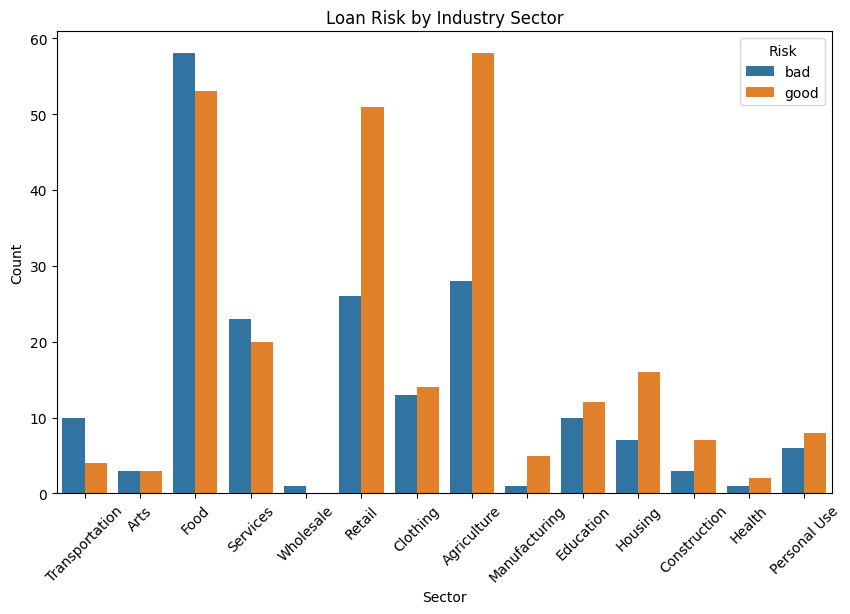

In [28]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='sector', hue='Risk')
plt.title('Loan Risk by Industry Sector')
plt.xlabel('Sector')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

The **Wholesale sector** currently poses the highest risk-to-reward ratio for the credit union. In the historical dataset, this sector consists entirely of "Bad" loans (represented by the blue bar) with zero recorded "Good" loans (orange bar). Because it has a 100% default rate within this sample, offering zero successful repayments to offset the risk, the Wholesale industry represents the most toxic risk profile for the credit union.

### Credit Distribution

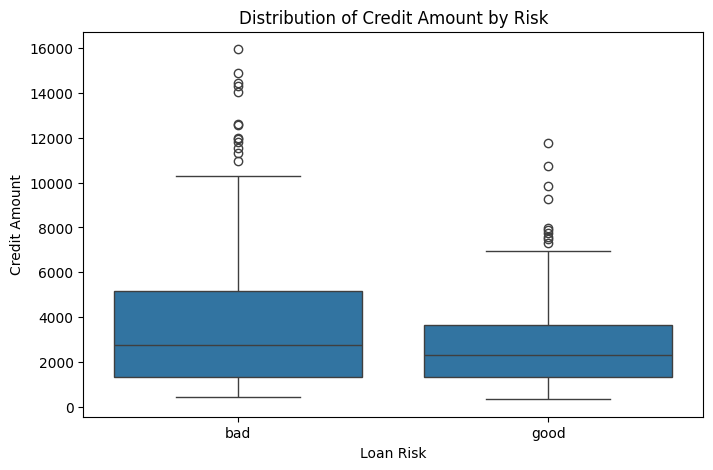

In [29]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Risk', y='Credit amount')
plt.title('Distribution of Credit Amount by Risk')
plt.xlabel('Loan Risk')
plt.ylabel('Credit Amount')
plt.show()

## NLP & Classification (Naive Bayes)

### Sentiment Analysis

In [30]:
sia = SentimentIntensityAnalyzer()
# Assigning a sentiment score to each narrative
df['Sentiment_Score'] = df['Clean_Purpose'].apply(lambda x: sia.polarity_scores(x)['compound'])

### Text Classification (Naive Bayes)

In [31]:
# Assuming 'Risk_encoded' is the target (0/1)
y = df['Risk_encoded']

X_train_txt, X_test_txt, y_train, y_test = train_test_split(X_text, y, test_size=0.3, random_state=42)

nb_model = MultinomialNB()
nb_model.fit(X_train_txt, y_train)
y_pred_txt = nb_model.predict(X_test_txt)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_txt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_txt))

Accuracy: 0.5939849624060151
Confusion Matrix:
 [[21 27]
 [27 58]]


### Bad Risk Words

In [32]:
bad_class_prob_sorted = nb_model.feature_log_prob_[1, :].argsort()[::-1]
top_5_bad_words = np.take(vectorizer.get_feature_names_out(), bad_class_prob_sorted[:5])
print("Top 5 Bad words:", top_5_bad_words)

Top 5 Bad words: ['buy' 'purchase' 'sell' 'additional' 'feed']


## Transparent Modeling - Decision Trees

### Visualizing Model

Model WITH Sentiment Score

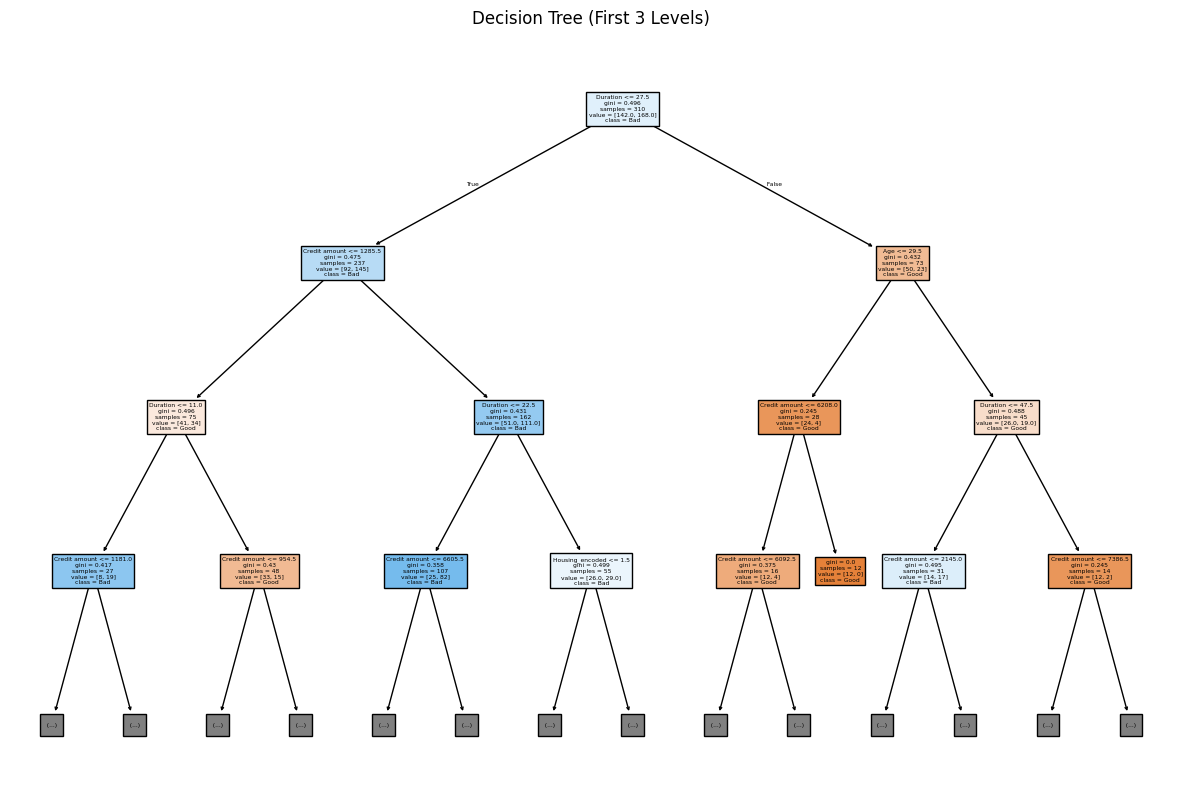

In [33]:
# Defining structured features
features = ['Age', 'Credit amount', 'Duration', 'Sex_encoded', 'Housing_encoded', 'Sentiment_Score']
X_structured = df[features]

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_structured, y, test_size=0.3, random_state=42)

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_dt, y_train_dt)

# Visualizing first 3 levels
plt.figure(figsize=(15, 10))
plot_tree(dt_model, feature_names=features, class_names=['Good', 'Bad'], filled=True, max_depth=3)
plt.title("Decision Tree (First 3 Levels)")
plt.show()

In [34]:
# Predicting set using trained Decision Tree
y_pred_dt = dt_model.predict(X_test_dt)

# Calculating the accuracy
dt_accuracy = accuracy_score(y_test_dt, y_pred_dt)
print("Decision Tree Accuracy (WITH Sentiment Score):", dt_accuracy)

Decision Tree Accuracy (WITH Sentiment Score): 0.6466165413533834


Model WITHOUT Sentiment Score

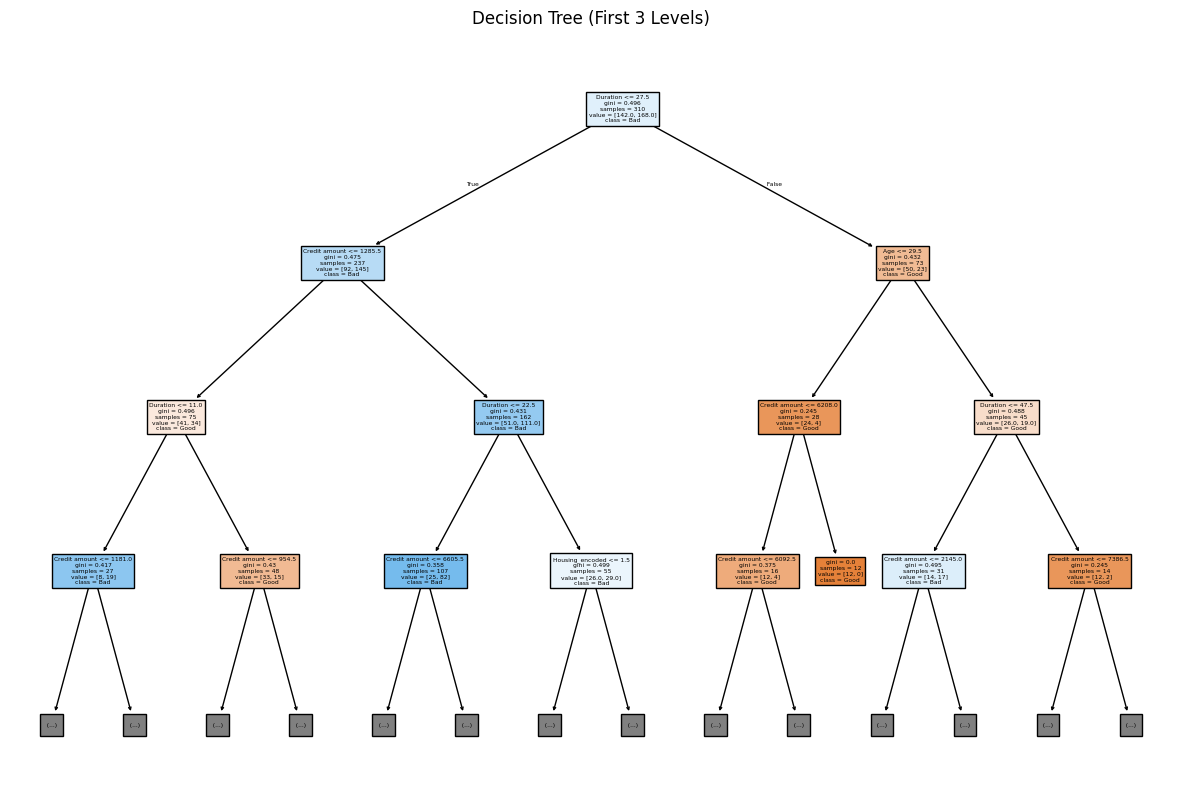

In [35]:
# Defining structured features
features = ['Age', 'Credit amount', 'Duration', 'Sex_encoded', 'Housing_encoded']
X_structured = df[features]

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_structured, y, test_size=0.3, random_state=42)

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_dt, y_train_dt)

# Visualizing first 3 levels
plt.figure(figsize=(15, 10))
plot_tree(dt_model, feature_names=features, class_names=['Good', 'Bad'], filled=True, max_depth=3)
plt.title("Decision Tree (First 3 Levels)")
plt.show()

In [36]:
# 1. Defining features WITHOUT Sentiment_Score
features_no_sentiment = ['Age', 'Credit amount', 'Duration', 'Sex_encoded', 'Housing_encoded']

# 2. Re-creating the X dataset so it drops the sentiment column
X_structured_no_sent = df[features_no_sentiment]

# 3. Re-splitting the new data
X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(X_structured_no_sent, y, test_size=0.3, random_state=42)

# 4. Initializing a NEW model and training it on the new data
dt_model_no_sent = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model_no_sent.fit(X_train_ns, y_train_ns)

# 5. Predicting and calculating accuracy for the NEW model
y_pred_ns = dt_model_no_sent.predict(X_test_ns)
accuracy_no_sent = accuracy_score(y_test_ns, y_pred_ns)

print("Decision Tree Accuracy (WITHOUT Sentiment Score):", accuracy_no_sent)

Decision Tree Accuracy (WITHOUT Sentiment Score): 0.6466165413533834


## Comparision
###  Does adding the "Sentiment Score" from Part 3 improve the accuracy of the Decision Tree?
Adding the Sentiment Score did not improve the accuracy of the Decision Tree. Because it was not a strong enough mathematical predictor compared to financial factors like Duration and Credit Amount, the algorithm assigned it a low feature importance and relied on other variables to make its splits.

### Feature Importance

C:\Users\dhyey\AppData\Local\Temp\ipykernel_8156\2703932448.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette='mako')


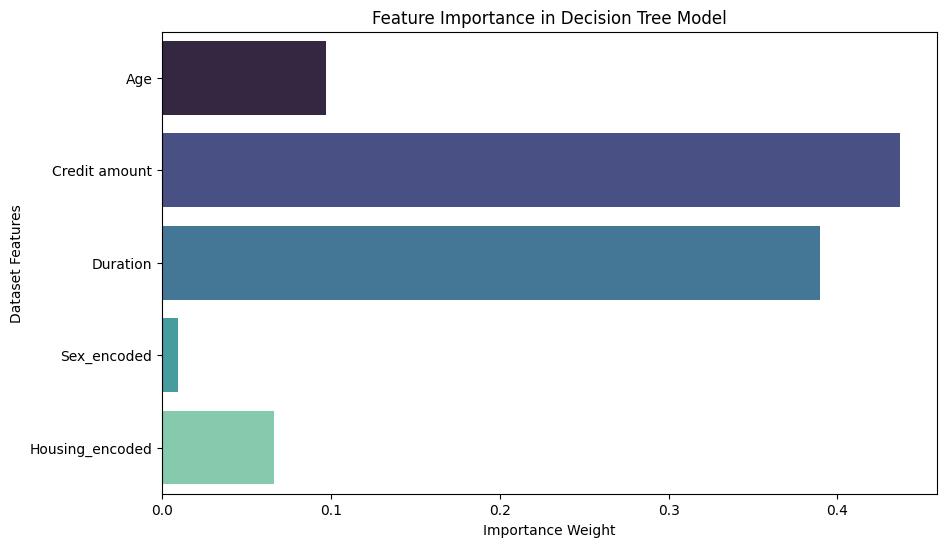

In [39]:
# Identifying and plotting Feature Importance
plt.figure(figsize=(10, 6))

importances = dt_model.feature_importances_
sns.barplot(x=importances, y=features, palette='mako')

# Adding title and axis labels
plt.title('Feature Importance in Decision Tree Model')
plt.xlabel('Importance Weight')
plt.ylabel('Dataset Features')
plt.show()

### Feature Importance Analysis:
Based on the feature importance extraction, **Credit amount** is the most influential variable in the model's decision-making process. It carries the highest importance weight, indicating that the total size of the loan provides the strongest mathematical splits for separating "Good" and "Bad" risk.

# Unsupervised Learning - Clustering

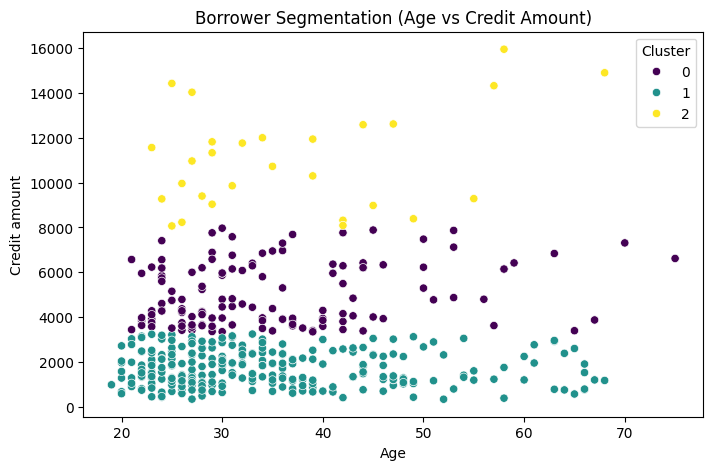

Cluster Centers:
    Credit amount        Age
0    4984.715328  34.759124
1    1692.467626  34.525180
2   11001.535714  36.964286


In [38]:
# Groupping borrowers into 3 distinct segments based on Credit amount and Age
cluster_data = df[['Credit amount', 'Age']]

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(cluster_data)

# Visualizing the clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='Credit amount', hue='Cluster', palette='viridis')
plt.title('Borrower Segmentation (Age vs Credit Amount)')
plt.show()

# Getting cluster centers to help name personas
print("Cluster Centers:\n", pd.DataFrame(kmeans.cluster_centers_, columns=['Credit amount', 'Age']))

## Cluster Personas

### Cluster 1: The "Micro-Borrowers"
#### Description: This segment represents borrowers in their mid-30s who are taking out very small loans (averaging around $1,692). These are likely early-stage startups, freelancers or side-hustlers who only need a small injection of cash for minor equipment or basic initial expenses.

### Cluster 0: The "Mid-Size Strivers"
#### Description: This is the middle-ground segment. Also in their mid-30s, these borrowers are seeking moderate loan amounts (averaging around $4,984). They likely represent growing, standard small businesses that need operational capital to scale up, hire an employee or run marketing campaigns.

### Cluster 2: The "Established Expanders"
#### Description: This segment consists of slightly older borrowers (averaging 37 years old) who are taking out the largest loans by far (averaging over $11,000). Because they are older and asking for significant capital, these represent mature, established businesses making major investments such as purchasing commercial property or heavy machinery.

# Managerial Decision Making

## 1. Safest Borrower Automation Rule
### Based on the Decision Tree model, the safest segment of borrowers is defined by the following rule branch:

### Loan Duration: Less than or equal to 27.5 months. (The model identified this as the single most important starting split at the root of the tree)

### Applicant Age: 29.5 years old or younger

### Credit Amount: Less than or equal to $7,386.50

### Business Interpretation: By tracing the tree from the root down to the purest leaf node, the AI indicates that younger applicants requesting lower-value, shorter-term loans represent the lowest risk to the credit union. Because historical defaults are virtually non-existent in this specific branch, applications meeting these three exact criteria are prime candidates for the "Auto-Approve" system.

## 2. Automatic Rejection Cut-off Score
When my Decision Tree predicts an outcome, it does not just guess "Good" or "Bad". It calculated the probabitlity (eg. There is 85% probability this loan is Bad)
### I recommend setting the cut-off probability score for an "Auto-Reject" at 0.80 (80%) for the "Bad" risk classification.

### Business Justification: If the Decision Tree model is 80% or more confident that a loan application will default, it should be automatically rejected. This high threshold serves a dual purpose: it aggressively filters out highly toxic loans (achieving the board's goal of reducing the 2-week manual review backlog) while remaining conservative enough to minimize "false negatives", ensuring that borderline applicants who might deserve a manual human review are not unfairly auto-rejected.

## 3. Customer Loan Rejection Justification

Dear Applicant,

Thank you for choosing Ontario Community Credit Union (OCCU) to support your small business journey. After a thorough review of your application, we are currently unable to approve your loan request.

To ensure every applicant is treated with complete fairness and objectivity, OCCU utilizes an automated risk-assessment model. This system compares the structural details of your application against years of historical lending data to determine the probability of successful repayment.

Our decision is strictly data-driven and is based entirely on the objective financial parameters of your request, rather than the quality or potential of your business idea. Specifically, our model flagged your application because the requested loan duration and the total credit amount exceed the risk thresholds our system has identified as safe for your specific demographic profile. Our historical data strongly indicates that applications combining this specific repayment timeline with this level of funding carry a significantly elevated risk of overextension.

We encourage you to reapply in the future. Adjusting your application to request a smaller initial credit amount or a shorter loan duration may align your file more closely with our automated approval criteria.

Sincerely,

OCCU